In [ ]:
import os
from pathlib import Path
# Ensure CWD is repo root so relative paths and `tools.*` imports resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")


# Notebook for new ideas

## Pivoting decisions

In [1]:
import os
import json
import pymssql

import pandas as pd
import numpy as np

from pprint import pprint
from datetime import datetime, date
from typing import List, Dict, Any, Optional
from langchain_openai import  AzureChatOpenAI, ChatOpenAI
from langchain_core.language_models.chat_models import BaseChatModel
from dotenv import load_dotenv

from sqlalchemy import (
    create_engine, Column, Integer, String, Float, Date, Boolean, Text, JSON
)
from sqlalchemy.orm import declarative_base, sessionmaker, Session
from sqlalchemy.schema import DDL, CheckConstraint
from sqlalchemy.engine import Engine

from tools.schema import (
    NERDecisao,
    Obrigacao,
    Recomendacao,
    ResponsibleChoice
)

from tools.utils import (
    get_decisions_by_year_and_months,
    get_decisions_by_process,
    get_decisions_by_dates,
    run_ner_pipeline_for_dataframe,
    run_obrigacao_pipeline,
    get_connection
)

load_dotenv()

gpt4turbo = AzureChatOpenAI(
    deployment_name="gpt-4-turbo",
    model_name="gpt-4",
)

'''
gpt4turbo = ChatOpenAI(
    model="gpt-4-turbo",
    temperature=0.0
)
'''

extractor_decisao_gpt4turbo = gpt4turbo.with_structured_output(NERDecisao, include_raw=False, method="json_schema")
extractor_obrigacao_gpt4turbo = gpt4turbo.with_structured_output(
    Obrigacao, include_raw=False, method="json_schema")
extractor_recomendacao_gpt4turbo = gpt4turbo.with_structured_output(
    Recomendacao, include_raw=False, method="json_schema")
extractor_responsible = gpt4turbo.with_structured_output(ResponsibleChoice, include_raw=False, method="json_schema")


c:\Users\05911205424\Documents\Dev\decicontas.br\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:1784: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(
c:\Users\05911205424\Documents\Dev\decicontas.br\.venv\Lib\site-packages\langchain_openai\chat_models\base.py:1784: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [5]:
dec = get_decisions_by_year_and_months(2024, range(1, 13))

In [14]:
sql = ''' 
SELECT 
    p.IdProcesso as id_processo,
    CONCAT(p.Numero_Processo, '/', p.Ano_Processo) AS processo,
    o.Nome AS orgao_responsavel, 
    o.IdOrgao AS id_orgao_responsavel,
    gp.Nome AS nome_responsavel,
    gp.Documento AS documento_responsavel,
    gp.TipoPessoa AS tipo_responsavel,
    gp.IdPessoa AS id_pessoa,
    d.[monocratica],
    d.[codigo_tipo_processo],
    d.[descricao],
    d.[TipoVoto] as tipo_voto,
    d.[VotoEscolhido] as voto_escolhido,
    d.[IdComposicaoPauta] as id_composicao_pauta,
    d.[numero_sessao],
    d.[ano_sessao],
    d.[DataSessao] as data_sessao,
    d.[DataEncerramentoSessao] as data_encerramento_sessao,
    d.[numeroResultado] as numero_resultado,
    d.[anoResultado] as ano_resultado,
    d.[resultadoTipo] as resultado_tipo,
    d.[idVotoPauta] as id_voto_pauta,
    d.[idVotoDecisao] as id_voto_decisao,
    d.[ementa],
    d.[assunto],
    d.[NumeroProcesso] as numero_processo,
    d.[AnoProcesso] as ano_processo,
    d.[interessado],
    d.[OrgaoOrigem] as orgao_origem,
    d.[isVotoDivergente] as is_voto_divergente,
    d.[IdVotoConcordado] as id_voto_concordado,
    d.[Relatorio] as relatorio,
    d.[FundamentacaoVoto] as fundamentacao_voto,
    d.[Conclusao] as conclusao,
    d.[texto_acordao],
    d.[SetorVoto] as setor_voto
    FROM processo.dbo.vw_ia_votos_acordaos_decisoes d
    INNER JOIN processo.dbo.Processos p 
        ON d.IdProcesso = p.IdProcesso
    INNER JOIN processo.dbo.Orgaos o 
        ON p.IdOrgaoEnvolvido = o.IdOrgao 
    INNER JOIN processo.dbo.Pro_ProcessosResponsavelDespesa pprd 
        ON pprd.IdProcesso = p.IdProcesso 
    INNER JOIN processo.dbo.GenPessoa gp 
        ON gp.IdPessoa = pprd.IdPessoa 
    WHERE p.IdProcesso IN (
        SELECT ndec.IdProcesso
        FROM BdDIP.dbo.NERObrigacao nobr
        INNER JOIN BdDIP.dbo.NERDecisao ndec ON ndec.IdNerDecisao = nobr.IdNerDecisao
    )
'''
dec_with_obrigacao = pd.read_sql(sql, con=get_connection().engine)

In [15]:
dec_with_obrigacao

,id_processo,processo,orgao_responsavel,id_orgao_responsavel,nome_responsavel,documento_responsavel,tipo_responsavel,id_pessoa,monocratica,codigo_tipo_processo,...,ano_processo,interessado,orgao_origem,is_voto_divergente,id_voto_concordado,relatorio,fundamentacao_voto,conclusao,texto_acordao,setor_voto
0,413817,009819/2016,PREFEITURA MUNICIPAL DE BOM JESUS,351,Edmundo Aires de Melo Júnior,46532331449,F,3934,0,REL,...,2016,PREF.MUN.BOM JESUS ...,PREFEITURA MUNICIPAL DE BOM JESUS,False,None,None,None,Apresento aos Excelentíssimos Srs. Conselheiro...,"\r\nVistos, relatados e discutidos estes autos...",GCAED
1,413817,009819/2016,PREFEITURA MUNICIPAL DE BOM JESUS,351,MINISTÉRIO PÚBLICO DO ESTADO DO RIO GRANDE DO ...,08539710000104,J,11963,0,REL,...,2016,PREF.MUN.BOM JESUS ...,PREFEITURA MUNICIPAL DE BOM JESUS,False,None,None,None,Apresento aos Excelentíssimos Srs. Conselheiro...,"\r\nVistos, relatados e discutidos estes autos...",GCAED
2,413817,009819/2016,PREFEITURA MUNICIPAL DE BOM JESUS,351,GLAUCIO PINTO GARCIA,51555921515,F,97106,0,REL,...,2016,PREF.MUN.BOM JESUS ...,PREFEITURA MUNICIPAL DE BOM JESUS,False,None,None,None,Apresento aos Excelentíssimos Srs. Conselheiro...,"\r\nVistos, relatados e discutidos estes autos...",GCAED
3,413817,009819/2016,PREFEITURA MUNICIPAL DE BOM JESUS,351,PREFEITURA MUNICIPAL DE BOM JESUS,08002404000126,J,12112,0,REL,...,2016,PREF.MUN.BOM JESUS ...,PREFEITURA MUNICIPAL DE BOM JESUS,False,None,None,None,Apresento aos Excelentíssimos Srs. Conselheiro...,"\r\nVistos, relatados e discutidos estes autos...",GCAED
4,413817,009819/2016,PREFEITURA MUNICIPAL DE BOM JESUS,351,José Nilson Pereira da Silva,79081193449,F,98675,0,REL,...,2016,PREF.MUN.BOM JESUS ...,PREFEITURA MUNICIPAL DE BOM JESUS,False,None,None,None,Apresento aos Excelentíssimos Srs. Conselheiro...,"\r\nVistos, relatados e discutidos estes autos...",GCAED
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,617115,302824/2025,PREFEITURA MUNICIPAL DE MACAU,412,OESTE VERDE PREMOLDADOS E ARTEFATOS DE CONCRET...,14032202000120,J,99357,0,REP,...,2025,xxx ...,TRIBUNAL DE CONTAS DO ESTADO,False,None,1.\tTrata-se de Representação com pedido caute...,"18.\tInsta acentuar, inicialmente, que, neste ...","77.\tDiante do exposto, em consonância com a U...","\r\nVistos, relatados e discutidos estes autos...",GCAED
201,617115,302824/2025,PREFEITURA MUNICIPAL DE MACAU,412,DLS CONSTRUÇÕES LTDA.,14217684000192,J,99356,0,REP,...,2025,xxx ...,TRIBUNAL DE CONTAS DO ESTADO,False,None,1.\tTrata-se de Representação com pedido caute...,"18.\tInsta acentuar, inicialmente, que, neste ...","77.\tDiante do exposto, em consonância com a U...","\r\nVistos, relatados e discutidos estes autos...",GCAED
202,617990,303123/2025,SECRETARIA MUNICIPAL DE SAÚDE DE NATAL,1276,BRUNO GENTIL DORE,09728866488,F,95135,0,DEN,...,2025,xxx ...,TRIBUNAL DE CONTAS DO ESTADO,False,None,Trata-se da análise de Denúncia formulada em f...,"Inicialmente, esclareço que os presentes autos...","Diante do exposto, concordando com o Ministéri...","\r\nVistos, relatados e discutidos estes autos...",GAMAR
203,617990,303123/2025,SECRETARIA MUNICIPAL DE SAÚDE DE NATAL,1276,Geraldo Souza Pinho Alves,00880012455,F,93074,0,DEN,...,2025,xxx ...,TRIBUNAL DE CONTAS DO ESTADO,False,None,Trata-se da análise de Denúncia formulada em f...,"Inicialmente, esclareço que os presentes autos...","Diante do exposto, concordando com o Ministéri...","\r\nVistos, relatados e discutidos estes autos...",GAMAR


In [17]:
dec_with_obrigacao.groupby(['id_processo'])['texto_acordao'].nunique().sort_values(ascending=False)

id_processo
550929    6
485062    3
506376    2
542296    2
540926    2
560871    2
413817    1
543414    1
543516    1
543538    1
543543    1
543545    1
543586    1
543589    1
545619    1
556805    1
556253    1
542777    1
556925    1
594996    1
612222    1
612469    1
612549    1
613474    1
616461    1
617115    1
542790    1
542750    1
542771    1
541236    1
526584    1
527062    1
536477    1
539246    1
540404    1
540517    1
541093    1
541094    1
541107    1
541458    1
542760    1
541683    1
541857    1
541900    1
541905    1
542058    1
542059    1
542188    1
542665    1
542734    1
617990    1
Name: texto_acordao, dtype: int64

In [19]:
dec_with_obrigacao[dec_with_obrigacao['id_processo'] == 550929].drop_duplicates(subset=['texto_acordao'], keep='first')

,id_processo,processo,orgao_responsavel,id_orgao_responsavel,nome_responsavel,documento_responsavel,tipo_responsavel,id_pessoa,monocratica,codigo_tipo_processo,...,ano_processo,interessado,orgao_origem,is_voto_divergente,id_voto_concordado,relatorio,fundamentacao_voto,conclusao,texto_acordao,setor_voto
46,550929,002489/2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL,554,ALVAMAR SILVA DO VALE,06401324481,F,83843,0,REP,...,2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL - URBAN...,TRIBUNAL DE CONTAS DO ESTADO,False,None,Trata-se de representação proposta pelo Minist...,"Com efeito, após a conclusão da instrução proc...","Ante ao exposto, em consonância integral com a...","Vistos, relatados e discutidos estes autos, A...",GCADE
91,550929,002489/2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL,554,URBANA - COMPANHIA DE SERVIÇOS URBANOS DE NATAL,08498701000104,J,11445,0,REP,...,2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL - URBAN...,TRIBUNAL DE CONTAS DO ESTADO,False,None,Versam os presentes autos sobre Representação ...,"De início, verifico que os Pedidos de Reconsid...","Ante o exposto, VOTO pelo CONHECIMENTO e PARCI...","\r\nVistos, relatados e discutidos estes autos...",GCGIL
97,550929,002489/2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL,554,ALVAMAR SILVA DO VALE,06401324481,F,83843,0,REP,...,2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL - URBAN...,TRIBUNAL DE CONTAS DO ESTADO,False,None,Trata-se de Agravo (Apensado nº 004152/2022-TC...,"De início, observo que o Agravo em análise foi...","À vista do exposto, em dissonância com o Minis...","Vistos, relatados e discutidos os autos do pro...",GCCTH
104,550929,002489/2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL,554,ALVAMAR SILVA DO VALE,06401324481,F,83843,0,REP,...,2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL - URBAN...,TRIBUNAL DE CONTAS DO ESTADO,False,None,Trata-se de Pedido de Reconsideração (Apensado...,II.1 – Do conhecimento do Pedido de Reconsider...,"À vista do exposto, em consonância parcial com...","Vistos, relatados e discutidos estes autos, AC...",GCCTH
118,550929,002489/2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL,554,URBANA - COMPANHIA DE SERVIÇOS URBANOS DE NATAL,08498701000104,J,11445,0,REP,...,2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL - URBAN...,TRIBUNAL DE CONTAS DO ESTADO,False,None,1.\tTrata-se de Representação formulada pelo M...,"27.\tInicialmente, vejo que, quanto às questõe...","113.\tDiante do exposto, em discordância da Un...","Vistos, relatados e discutidos estes autos, em...",GCAED
125,550929,002489/2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL,554,ALVAMAR SILVA DO VALE,06401324481,F,83843,0,REP,...,2021,COMPANHIA DE SERVIÇOS URBANOS DE NATAL - URBAN...,TRIBUNAL DE CONTAS DO ESTADO,False,None,1.\tTrata-se de processo que se encontra em fa...,"10.\tDe início, informo que dispensei a oitiva...","35.\tDiante do exposto, VOTO no sentido de CON...","\r\nVistos, relatados e discutidos estes autos...",GCAED


## Ontologies

In [1]:
import sys, os

from owlready2 import *

In [2]:
onto_path.append(os.path.expanduser("~/ontologias"))

In [ ]:
world = World()

In [30]:
dul = world.get_ontology("file://" + os.path.abspath("DUL.rdf")).load()
tce = world.get_ontology("http://tce.rn.gov.br/tce.owl")

In [ ]:
# Ontologia do TCE
tce = world.get_ontology("http://tce.rn.gov.br/tce.owl")
with tce:
    # ======== CLASSES (alinhadas ao DUL) ========
    class Processo(dul.SocialObject): pass                     # Processo (dossiê/autos)
    class Acordao(dul.SocialObject): pass                      # Texto/ato decisório como objeto social
    class SessaoJulgamento(dul.Event): pass                    # Evento (perdurant)
    class Obrigacao(dul.SocialObject): pass                    # A entidade normativa "obrigação"
    class MultaCominatoria(dul.SocialObject): pass             # A multa por descumprimento (título)
    class OrgaoResponsavel(dul.Agent): pass                    # Órgão (agente coletivo)
    class PessoaResponsavel(dul.Agent): pass                   # Pessoa física (agente)

    # (Opcional) Vocabulário controlado para tipo da obrigação
    class TipoObrigacao(Thing):
        namespace = tce
        pass
    # Instâncias do vocabulário
    tipo_fazer       = TipoObrigacao("Fazer")
    tipo_nao_fazer   = TipoObrigacao("NaoFazer")

    # ======== PROPRIEDADES OBJETO ========
    class isDerivedFrom(ObjectProperty):
        # Obrigação deriva de um Acórdão
        domain = [Obrigacao]
        range  = [Acordao]

    class emittedIn(ObjectProperty):
        # Acordão emitido em uma Sessão de Julgamento
        domain = [Acordao]
        range  = [SessaoJulgamento]

    class temOrgaoResponsavel(ObjectProperty, FunctionalProperty):
        # Campo: orgao_responsavel (jurídica). Se não houver, "Desconhecido".
        domain = [Obrigacao]
        range  = [OrgaoResponsavel]

    class temPessoaResponsavel(ObjectProperty):
        # Pessoas responsáveis (podem ser várias)
        domain = [Obrigacao]
        range  = [PessoaResponsavel]

    class temMultaCominatoria(ObjectProperty, FunctionalProperty):
        # Associação 1–0/1: uma obrigação pode ter uma multa cominatória
        domain = [Obrigacao]
        range  = [MultaCominatoria]

    class tipo(ObjectProperty, FunctionalProperty):
        # Liga Obrigacao -> TipoObrigacao (Fazer | NaoFazer)
        domain = [Obrigacao]
        range  = [TipoObrigacao]

    class solidariosMultaCominatoria(ObjectProperty):
        # Lista de responsáveis solidários da multa cominatória
        domain = [MultaCominatoria]
        range  = [PessoaResponsavel]

    # ======== PROPRIEDADES DADO (funcionais onde faz sentido) ========
    class descricao_obrigacao(DataProperty, FunctionalProperty):
        domain = [Obrigacao];  range = [str]

    class prazo_texto(DataProperty, FunctionalProperty):
        # Ex.: "90 dias" (texto extraído do acórdão)
        domain = [Obrigacao];  range = [str]

    class data_cumprimento(DataProperty, FunctionalProperty):
        # Use "YYYY-MM-DD" (string) para manter compat compatível com xsd:date
        domain = [Obrigacao];  range = [str]

    class texto_acordao(DataProperty):
        # Armazena o trecho relevante ou o acórdão inteiro, se necessário
        domain = [Acordao];    range = [str]

    # --- Multa cominatória (campos do prompt) ---
    class tem_multa_cominatoria(DataProperty, FunctionalProperty):
        # espelho booleano; opcional (pode ser inferido por temMultaCominatoria)
        domain = [Obrigacao];  range = [bool]

    class valor_multa_cominatoria(DataProperty, FunctionalProperty):
        # valor numérico (use float; se quiser precisão decimal, trate na camada de aplicação)
        domain = [MultaCominatoria];  range = [float]

    class periodo_multa_cominatoria(DataProperty, FunctionalProperty):
        # Ex.: "por dia", "por semana", "R$500/dia", etc. (texto do acórdão)
        domain = [MultaCominatoria];  range = [str]

    class e_multa_cominatoria_solidaria(DataProperty, FunctionalProperty):
        domain = [MultaCominatoria];  range = [bool]

    class nome_responsavel_multa_cominatoria(DataProperty):
        # redundante se modelar a pessoa como indivíduo; mantenho pq está no prompt
        domain = [MultaCominatoria];  range = [str]

    class documento_responsavel_multa_cominatoria(DataProperty):
        domain = [MultaCominatoria];  range = [str]

    # --- Metadados úteis das entidades-agente ---
    class nome(DataProperty, FunctionalProperty):
        domain = [PessoaResponsavel, OrgaoResponsavel]; range = [str]

    class documento(DataProperty, FunctionalProperty):
        # CPF/CNPJ; use máscara na aplicação
        domain = [PessoaResponsavel, OrgaoResponsavel]; range = [str]

# Salvar para inspecionar no Protégé
world.save(file="tce_model.owl", format="rdfxml")
print("Salvo em tce_model.owl")

Salvo em tce_model.owl


In [33]:
dul.SocialObject

DUL.SocialObject

In [34]:
dul

get_ontology("http://www.ontologydesignpatterns.org/ont/dul/DUL.owl#")

# Gráficos

In [9]:
sql_obrigacao = ''' 
SELECT [IdObrigacao]
      ,[IdProcesso]
      ,[IdComposicaoPauta]
      ,[IdVotoPauta]
      ,[DescricaoObrigacao]
      ,[DeFazer]
      ,[Prazo]
      ,[DataCumprimento]
      ,[OrgaoResponsavel]
      ,org.NomeOrgao 
      ,[IdOrgaoResponsavel]
      ,[TemMultaCominatoria]
      ,[NomeResponsavelMultaCominatoria]
      ,[DocumentoResponsavelMultaCominatoria]
      ,[IdPessoaMultaCominatoria]
      ,[ValorMultaCominatoria]
      ,[PeriodoMultaCominatoria]
      ,[EMultaCominatoriaSolidaria]
      ,[SolidariosMultaCominatoria]
      ,[Cancelado]
  FROM [BdDIP].[dbo].[Obrigacao] o
  INNER JOIN [Bdc].dbo.vw_Gen_Orgao org ON o.IdOrgaoResponsavel = org.IdOrgao
'''
df_ob = pd.read_sql(sql_obrigacao, con=get_connection().engine)

C:\Users\05911205424\AppData\Local\Temp\ipykernel_9408\1288441485.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), ha="right")


Text(0, 0.5, 'Órgão Responsável')

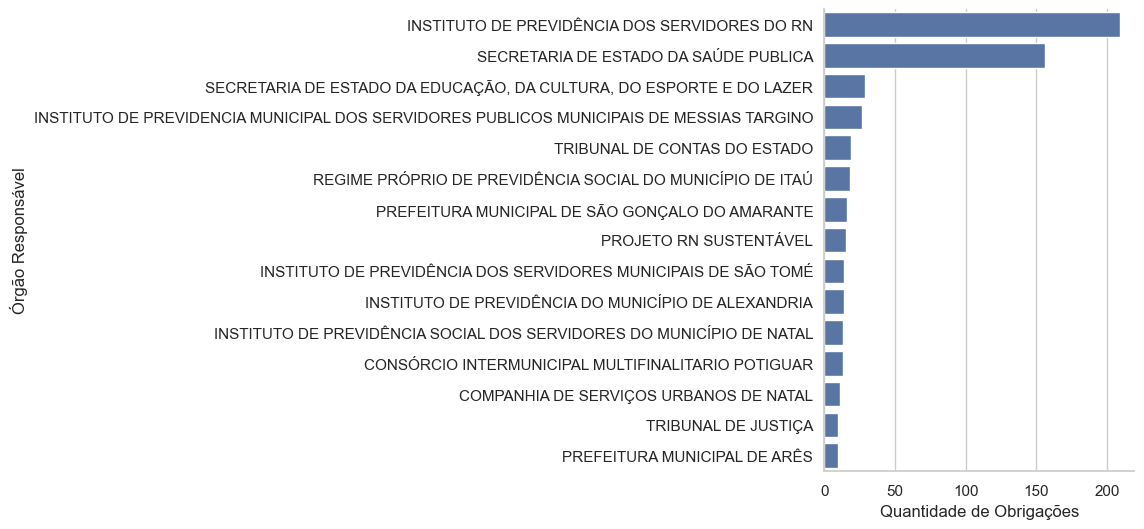

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Quantos órgãos mostrar
top_n = 15

# Conta obrigações por NomeOrgao
df_count = (
    df_ob["NomeOrgao"]
    .value_counts()
    .head(top_n)
    .reset_index()
)

df_count.columns = ["NomeOrgao", "qtd_obrigacoes"]

# Estilo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(4, 6))

ax = sns.barplot(
    data=df_count,
    x="qtd_obrigacoes",
    y="NomeOrgao"
)

sns.despine(top=True, right=True)

# Alinhamento dos labels Y
ax.set_yticklabels(ax.get_yticklabels(), ha="right")
ax.tick_params(axis="y", pad=2)

ax.set_xlabel("Quantidade de Obrigações")
ax.set_ylabel("Órgão Responsável")


